# 04 - Metod najbližih suseda i slučajne šume

U prethodnoj svesci videli smo da linearni modeli ne mogu da opišu vezu između sata u danu,
tipa dana i potražnje, jer ta veza nije linearna i sadrži interakcije atributa.

U ovoj svesci učimo dva modela koji tu vezu mogu da nauče:

1. metod k najbližih suseda
2. slučajne šume

Oba modela imaju metaparametre koje treba podesiti. Za to koristimo skup za validaciju
iz sveske 02, a skup za testiranje ostavljamo isključivo za konačnu ocenu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import preprocessing
from sklearn import neighbors
from sklearn import ensemble
from sklearn import metrics

np.random.seed(7)

# Učitavanje pripremljenih podataka

In [2]:
paket = joblib.load('../data/pripremljeno.joblib')

X = paket['X']
y = paket['y']
kolone = paket['kolone']

h_trening = paket['h_trening']
h_validacija = paket['h_validacija']
h_test = paket['h_test']

n_trening = paket['n_trening']
n_validacija = paket['n_validacija']
n_test = paket['n_test']

Za razliku od sveske 03, ovde koristimo sva tri skupa. Na skupu za treniranje učimo model
za različite vrednosti metaparametara, na skupu za validaciju biramo najbolju vrednost,
a na skupu za testiranje ocenjujemo konačni model.

Konačni model obučavamo na uniji skupova za treniranje i validaciju, jer smo metaparametre
već izabrali, pa nema razloga da taj deo podataka ostane neiskorišćen.

In [3]:
x_train = X[h_trening]
y_train = y[h_trening]

x_validation = X[h_validacija]
y_validation = y[h_validacija]

x_test = X[h_test]
y_test = y[h_test]

h_trening_validacija = h_trening | h_validacija
x_train_validation = X[h_trening_validacija]
y_train_validation = y[h_trening_validacija]

print('trening:           ', x_train.shape)
print('validacija:        ', x_validation.shape)
print('trening+validacija:', x_train_validation.shape)
print('test:              ', x_test.shape)

trening:            (6916, 52)
validacija:         (1729, 52)
trening+validacija: (8645, 52)
test:               (8734, 52)


# Standardizacija podataka

Metod najbližih suseda računa rastojanja između instanci, pa je standardizacija neophodna.
Bez nje bi atributi sa većim opsegom vrednosti dominirali rastojanjem.

Statistike učimo samo na podacima koji ulaze u obučavanje. Za fazu izbora metaparametara
to je skup za treniranje, a za konačni model unija treninga i validacije.

In [4]:
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)

x_train_s = scaler.transform(x_train)
x_validation_s = scaler.transform(x_validation)

In [5]:
scaler_final = preprocessing.StandardScaler()
scaler_final.fit(x_train_validation)

x_train_validation_s = scaler_final.transform(x_train_validation)
x_test_s = scaler_final.transform(x_test)

# Funkcija za evaluaciju

In [6]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    mae = metrics.mean_absolute_error(y_stvarno, y_predvidjeno)
    rmse = np.sqrt(metrics.mean_squared_error(y_stvarno, y_predvidjeno))
    r2 = metrics.r2_score(y_stvarno, y_predvidjeno)
    odstupanje = np.mean(y_predvidjeno - y_stvarno)
    print('%-38s MAE %6.1f  RMSE %6.1f  R2 %6.3f  odstupanje %+7.1f'
          % (naziv, mae, rmse, r2, odstupanje))
    return {'model': naziv, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'odstupanje': odstupanje}

Učitavamo rezultate iz sveske 03 da bismo nove modele poredili sa trivijalnom osnovom
i linearnom regresijom.

In [7]:
prethodni = pd.read_csv('../models/03_rezultati.csv')
prethodni

,model,MAE,RMSE,R2,odstupanje
0,trivijalna osnova,108.516420,157.050770,0.434793,-91.87431
1,linearna regresija,110.178359,158.026226,0.427750,-86.71467
2,linearna regresija sa težinama,110.296560,161.012460,0.405918,-88.13180


In [8]:
rezultati = prethodni.to_dict('records')

# Metod k najbližih suseda

Metod k najbližih suseda nema eksplicitnu formu, dakle ne uči koeficijente. Za novu instancu pronalazi k instanci iz skupa za treniranje koje su joj najbliže po rastojanju, a predviđanje je prosek njihovih vrednosti ciljne promenljive.

Jedini metaparametar je broj suseda k i biramo ga na skupu za validaciju.

In [9]:
ks = [1, 3, 5, 10, 15, 20, 30, 50, 100]

In [10]:
best_score = np.inf
best_k = None
mae_po_k = []

for k in ks:
    model = neighbors.KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train_s, y_train)

    y_validation_predicted = model.predict(x_validation_s)
    score = metrics.mean_absolute_error(y_validation, y_validation_predicted)
    mae_po_k.append(score)

    if score < best_score:
        best_score = score
        best_k = k

In [11]:
print('najbolje k:', best_k)
print('MAE na validaciji:', round(best_score, 1))

najbolje k: 50
MAE na validaciji: 42.9


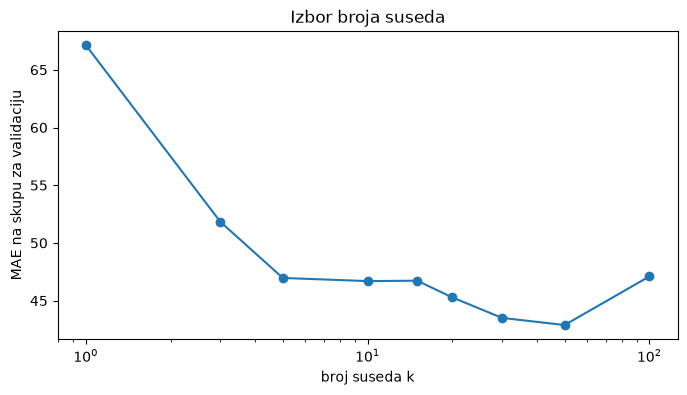

In [12]:
plt.figure(figsize=(8,4))
plt.plot(ks, mae_po_k, marker='o')
plt.xscale('log')
plt.xlabel('broj suseda k')
plt.ylabel('MAE na skupu za validaciju')
plt.title('Izbor broja suseda')
plt.show()

Greška na validaciji opada sa porastom k sve do pedeset suseda, a zatim ponovo raste.
Za k = 1 model pamti pojedinačne instance i greška je najveća.

Za izabranu vrednost k obučavamo model na uniji skupova za treniranje i validaciju
i ocenjujemo ga na skupu za testiranje.

In [13]:
model_knn = neighbors.KNeighborsRegressor(n_neighbors=best_k)
model_knn.fit(x_train_validation_s, y_train_validation)

KNeighborsRegressor(n_neighbors=50)

In [14]:
y_test_predicted_knn = model_knn.predict(x_test_s)

rezultati.append(oceni(y_test, y_test_predicted_knn, 'k najbližih suseda'))

k najbližih suseda                     MAE  116.3  RMSE  168.5  R2  0.349  odstupanje  -102.7


Na skupu za testiranje metod najbližih suseda je lošiji od trivijalne osnove, iako je na validaciji imao osetno manju grešku. Razlika između validacije i testa je velika i nije slučajna.

Skup za testiranje je 2012. godina, a svi susedi dolaze iz 2011. Model predviđa prosek suseda, pa ne može da predvidi vrednost veću od onih koje je video. Pošto je potražnja u 2012. porasla, model je sistematski potcenjuje za preko sto bicikala po satu, što se vidi u koloni odstupanja.

Osim toga, atributi su kodirani one-hot postupkom pa prostor u kojem se računaju rastojanja ima pedeset dve dimenzije. U takvom prostoru rastojanje dominantno zavisi od toga da li se dve instance poklapaju po satu i tipu dana, a numerički atributi kao temperatura imaju mali uticaj.

# Slučajne šume

Slučajna šuma je ansambl stabala odlučivanja, obučenih nad slučajno odabranim podskupovima instanci i, opciono, njihovih atributa. Kod regresije se predviđanja pojedinačnih stabala uprosečavaju, čime se smanjuje varijabilnost koja prati pojedinačno stablo.

Stabla nisu osetljiva na skalu atributa, pa šumu obučavamo na nestandardizovanim podacima. Za razliku od linearne regresije, šuma može da nauči interakcije atributa, jer u jednoj grani stabla može da testira sat, a u sledećoj tip dana.

Podešavamo dva metaparametra, broj stabala n_estimators i maksimalnu dubinu max_depth. Vrednost None za dubinu znači da se stabla granaju dok se listovi više ne mogu deliti.

In [15]:
brojevi_stabala = [50, 100, 200]
dubine = [5, 10, 20, None]

In [16]:
best_score = np.inf
best_params = {'n_estimators': None, 'max_depth': None}
mae_po_params = {}

for n in brojevi_stabala:
    for d in dubine:
        model = ensemble.RandomForestRegressor(n_estimators=n, max_depth=d, random_state=7)
        model.fit(x_train, y_train)

        y_validation_predicted = model.predict(x_validation)
        score = metrics.mean_absolute_error(y_validation, y_validation_predicted)
        mae_po_params[(n, d)] = score

        if score < best_score:
            best_score = score
            best_params['n_estimators'] = n
            best_params['max_depth'] = d

In [17]:
print('najbolji metaparametri:', best_params)
print('MAE na validaciji:', round(best_score, 1))

najbolji metaparametri: {'n_estimators': 50, 'max_depth': None}
MAE na validaciji: 45.9


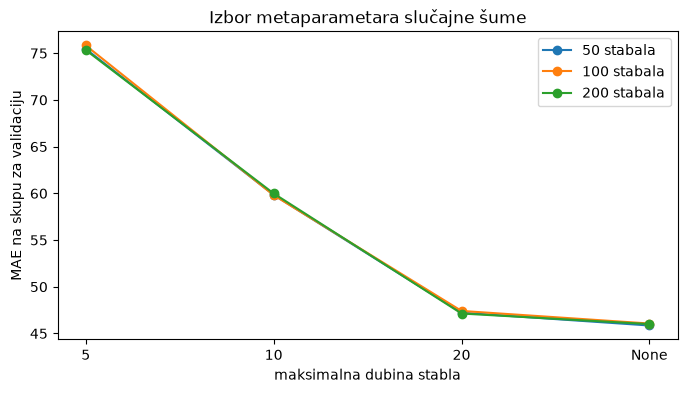

In [18]:
plt.figure(figsize=(8,4))

for n in brojevi_stabala:
    vrednosti = [mae_po_params[(n, d)] for d in dubine]
    plt.plot(range(len(dubine)), vrednosti, marker='o', label='%d stabala' % n)

plt.xticks(range(len(dubine)), [str(d) for d in dubine])
plt.xlabel('maksimalna dubina stabla')
plt.ylabel('MAE na skupu za validaciju')
plt.title('Izbor metaparametara slučajne šume')
plt.legend()
plt.show()

Dubina stabla ima daleko veći uticaj od broja stabala. Plitka stabla sa dubinom pet
ne mogu da opišu vezu, a od dubine dvadeset naviše greška se više gotovo ne menja.
Broj stabala u ispitanom opsegu ne pravi razliku.

Za izabrane vrednosti obučavamo konačni model na uniji treninga i validacije.

In [19]:
model_forest = ensemble.RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                              max_depth=best_params['max_depth'],
                                              random_state=7)
model_forest.fit(x_train_validation, y_train_validation)

RandomForestRegressor(n_estimators=50, random_state=7)

In [20]:
y_test_predicted_forest = model_forest.predict(x_test)

rezultati.append(oceni(y_test, y_test_predicted_forest, 'slučajna šuma'))

slučajna šuma                          MAE   93.0  RMSE  129.7  R2  0.614  odstupanje   -81.2


Slučajna šuma je prvi model koji je bolji od trivijalne osnove na skupu za testiranje. Srednja apsolutna greška je za petnaestak bicikala manja, a koeficijent determinacije raste sa 0.44 na preko 0.6.

Šuma i dalje potcenjuje potražnju, za oko osamdeset bicikala po satu. To je zajedničkinproblem svih modela u ovom projektu i ne zavisi od izbora modela. Atribut yr u skupu za treniranje ima samo vrednost 0, pa nijedan model ne može iz njega da nauči da je 2012. drugačija od 2011. Model uči oblik potražnje, ali ne i njen nivo.

## Važnost atributa

Slučajna šuma omogućava procenu koliko je koji atribut doprineo predviđanju, na osnovu toga koliko su grananja po tom atributu smanjila grešku. Vrednosti su dostupne kroz atribut feature_importances_ i zbir im je jedan.

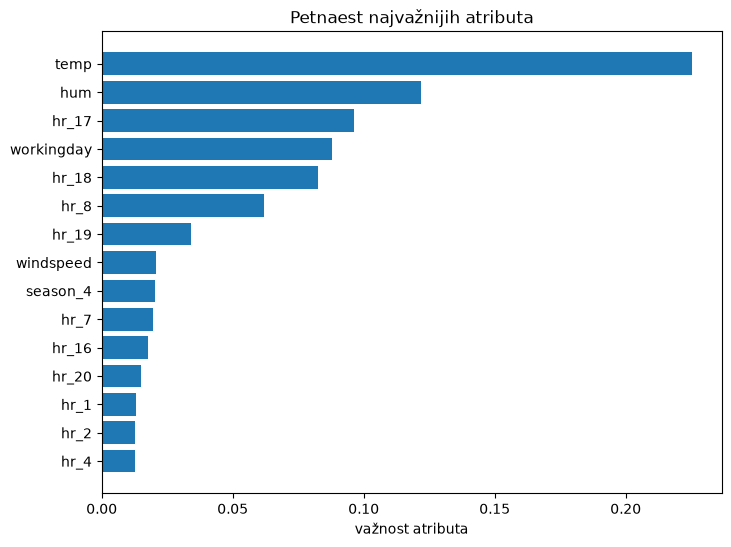

In [21]:
vaznost = pd.Series(model_forest.feature_importances_, index=kolone).sort_values(ascending=False)

plt.figure(figsize=(8,6))
plt.barh(vaznost.head(15).index[::-1], vaznost.head(15).values[::-1])
plt.xlabel('važnost atributa')
plt.title('Petnaest najvažnijih atributa')
plt.show()

In [22]:
sati = [k for k in kolone if k.startswith('hr_')]

print('zbir važnosti svih atributa sata:', round(vaznost[sati].sum(), 3))
print('temperatura:                     ', round(vaznost['temp'], 3))
print('vlažnost:                        ', round(vaznost['hum'], 3))
print('radni dan:                       ', round(vaznost['workingday'], 3))

zbir važnosti svih atributa sata: 0.454
temperatura:                      0.225
vlažnost:                         0.122
radni dan:                        0.088


Pojedinačno je najvažnija temperatura, ali kada se saberu svi atributi koji kodiraju sat u danu, oni zajedno nose skoro polovinu ukupne važnosti. Slede vlažnost i tip dana. Među satima se izdvajaju 17, 18 i 8, dakle sati špica.

To se poklapa sa onim što smo videli u analizi: potražnju najviše određuje sat u danu u kombinaciji sa tipom dana, a vremenski uslovi je koriguju.

# Poređenje sa nasumičnom podelom

Kao i u svesci 03, obučavamo iste modele na nasumičnoj podeli iste veličine, da bismo videli koliko ona precenjuje rezultat. Koristimo metaparametre izabrane na hronološkoj validaciji.

In [23]:
n_trening_validacija = n_trening | n_validacija

scaler_n = preprocessing.StandardScaler()
scaler_n.fit(X[n_trening_validacija])

model_knn_n = neighbors.KNeighborsRegressor(n_neighbors=best_k)
model_knn_n.fit(scaler_n.transform(X[n_trening_validacija]), y[n_trening_validacija])

model_forest_n = ensemble.RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                                max_depth=best_params['max_depth'],
                                                random_state=7)
model_forest_n.fit(X[n_trening_validacija], y[n_trening_validacija])

RandomForestRegressor(n_estimators=50, random_state=7)

In [24]:
oceni(y[n_test], model_knn_n.predict(scaler_n.transform(X[n_test])), 'k najbližih suseda, nasumična')
oceni(y_test, y_test_predicted_knn, 'k najbližih suseda, hronološka')
print()
oceni(y[n_test], model_forest_n.predict(X[n_test]), 'slučajna šuma, nasumična')
oceni(y_test, y_test_predicted_forest, 'slučajna šuma, hronološka')
print()

k najbližih suseda, nasumična          MAE   67.3  RMSE   99.7  R2  0.698  odstupanje   -12.3
k najbližih suseda, hronološka         MAE  116.3  RMSE  168.5  R2  0.349  odstupanje  -102.7

slučajna šuma, nasumična               MAE   37.3  RMSE   58.4  R2  0.896  odstupanje    +1.2
slučajna šuma, hronološka              MAE   93.0  RMSE  129.7  R2  0.614  odstupanje   -81.2



Na nasumičnoj podeli slučajna šuma ima koeficijent determinacije oko 0.9 i odstupanje blizu nule. Na hronološkoj podeli isti model, sa istim metaparametrima, ima koeficijent oko 0.6 i potcenjuje potražnju za osamdeset bicikala po satu.

Nasumična podela sakriva dve stvari. Prvo, susedni sati iz istog dana završe i u treningu i u testu, pa model interpolira. Drugo, obe godine su ravnomerno raspoređene u oba skupa, pa model vidi nivo iz 2012. već tokom obučavanja. Hronološka podela ne dozvoljava ni jedno ni drugo, i zato daje realnu sliku.

# Zbirni prikaz

In [25]:
tabela_rezultata = pd.DataFrame(rezultati).set_index('model')
tabela_rezultata.round(3)

,MAE,RMSE,R2,odstupanje
model,,,,
trivijalna osnova,108.516,157.051,0.435,-91.874
linearna regresija,110.178,158.026,0.428,-86.715
linearna regresija sa težinama,110.297,161.012,0.406,-88.132
k najbližih suseda,116.345,168.544,0.349,-102.667
slučajna šuma,92.986,129.738,0.614,-81.236


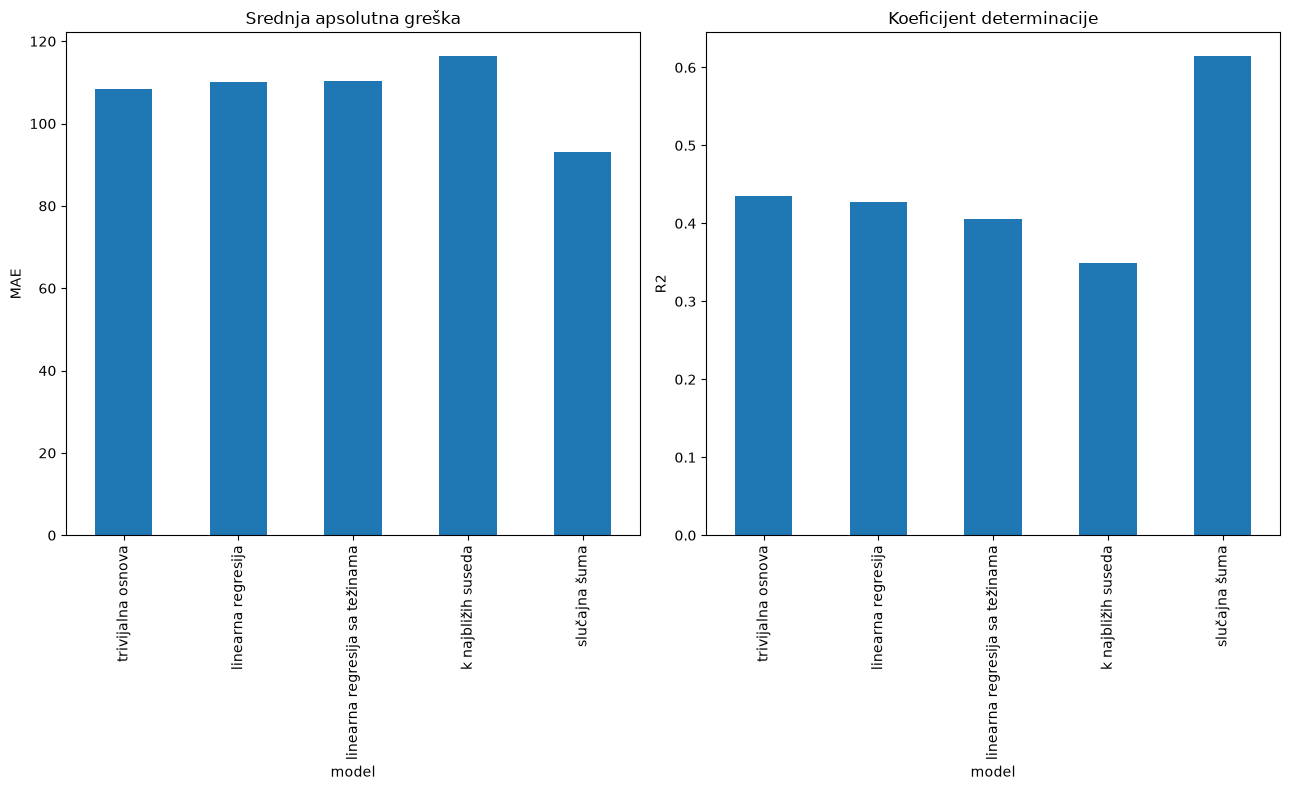

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 8))

tabela_rezultata['MAE'].plot(kind='bar', ax=ax[0])
ax[0].set_title('Srednja apsolutna greška')
ax[0].set_ylabel('MAE')

tabela_rezultata['R2'].plot(kind='bar', ax=ax[1])
ax[1].set_title('Koeficijent determinacije')
ax[1].set_ylabel('R2')

plt.tight_layout()
plt.show()

# Čuvanje modela

In [27]:
joblib.dump(model_knn, '../models/04_knn.joblib')
joblib.dump(model_forest, '../models/04_slucajna_suma.joblib')
joblib.dump(scaler_final, '../models/04_scaler.joblib')

tabela_rezultata.to_csv('../models/04_rezultati.csv')

print('sačuvano')

sačuvano


# Zaključci

1. Slučajna šuma je prvi model koji nadmašuje trivijalnu osnovu na hronološkoj podeli,
   jer može da nauči interakciju sata i tipa dana koju linearni modeli ne vide.

2. Metod najbližih suseda je na validaciji izgledao dobro, a na testu je pao ispod
   trivijalne osnove. Prosek suseda iz 2011. ne može da dostigne nivo potražnje iz 2012,
   a rastojanja u prostoru sa pedeset dve one-hot dimenzije slabo koriste numeričke atribute.

3. Kod slučajne šume dubina stabla je presudan metaparametar, a broj stabala u opsegu
   od pedeset do dvesta ne pravi razliku.

4. Sat u danu, kada se saberu svi njegovi one-hot atributi, nosi skoro polovinu važnosti.
   Slede temperatura, vlažnost i tip dana.

5. Svi modeli sistematski potcenjuju 2012. godinu, jer atribut godine u skupu
   za treniranje nema varijabilnost. Model uči oblik potražnje, ali ne i njen rast.

6. Nasumična podela daje koeficijent determinacije 0.9 naspram 0.6 na hronološkoj,
   za isti model. Razlika dolazi od interpolacije između susednih sati i od toga
   što nasumična podela pušta 2012. godinu u trening.

